# 01 Importing Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# 02 Import Data

In [2]:
path = r'C:\Users\isava\OneDrive\Documents\CareerFoundry\Data Immersion\PythonFundamentals\Instacart Basket Analysis'
path

'C:\\Users\\isava\\OneDrive\\Documents\\CareerFoundry\\Data Immersion\\PythonFundamentals\\Instacart Basket Analysis'

In [6]:
df = pd.read_pickle(os.path.join(path,'02 Data', 'Prepared Data','ords_prods_grouped_indicators.pkl'))

# 03 Visualizations

## Barplots

<Axes: xlabel='orders_day_of_week'>

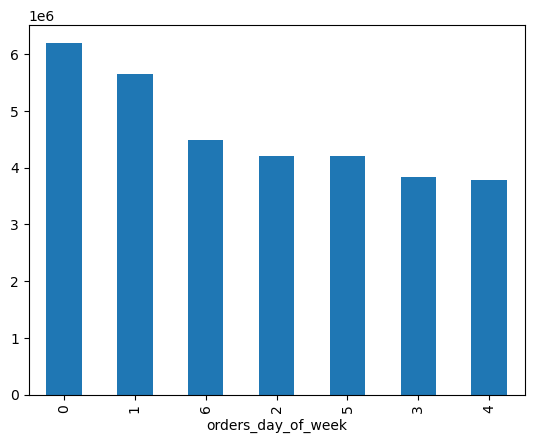

In [8]:
df['orders_day_of_week'].value_counts().plot.bar(title = "Order Per Day of Week")

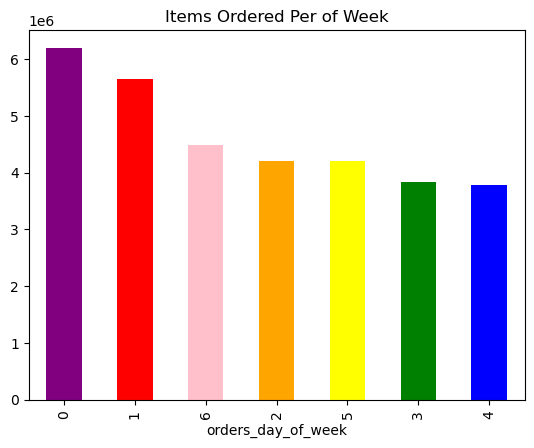

In [17]:
bar = df['orders_day_of_week'].value_counts().plot.bar(color =['purple', 'red', 'pink', 'orange', 'yellow', 'green', 'blue'], title = "Items Ordered Per Day of Week")

In [15]:
bar.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_orders_dow.png'))

In [29]:
len(df[df['orders_day_of_week'] == 0])/len(df)

0.19145838591675401

In [39]:
len(df[(df['orders_day_of_week'] == 0) | (df['orders_day_of_week'] == 1)]) / len(df)

0.36613064725879535

The busiest day of the week is Sunday taking up 19.14% of items ordered. The weekend items ordered makes up 36.6% of items ordered per week on average. 

## Histograms and Scatterplots

<Axes: ylabel='Frequency'>

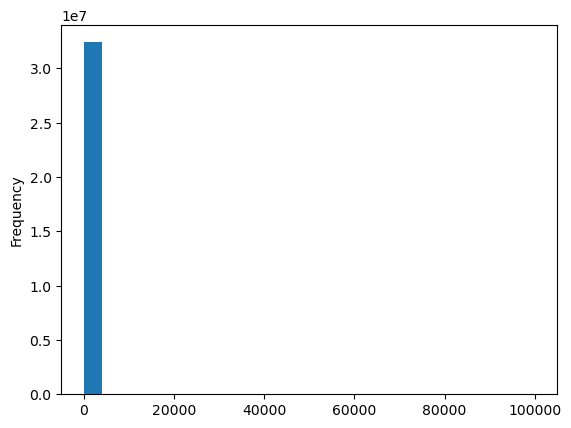

In [12]:
df['prices'].plot.hist(bins = 25)

In [13]:
df['prices'].mean()

11.980225638383445

In [14]:
df['prices'].median()

7.4

In [15]:
df['prices'].max()

99999.0

<Axes: xlabel='prices', ylabel='prices'>

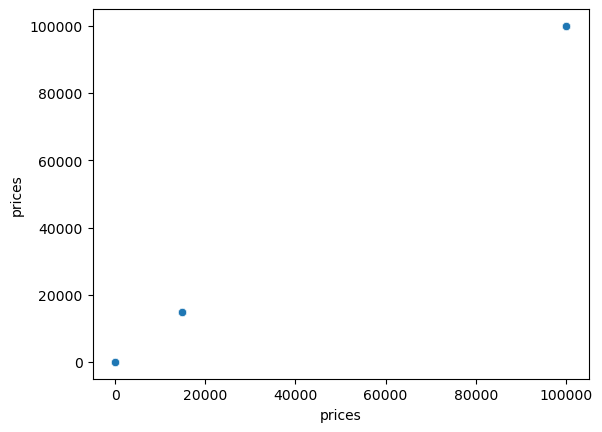

In [16]:
sns.scatterplot(x = 'prices', y = 'prices',data = df)

Outlier! The value around 20,000 is odd as well considering that most items are about $12. 

In [18]:
df.loc[df['prices'] > 100]

,order_id,user_id,order_number,orders_day_of_week,order_time_of_day,days_since_users_prior_order,product_id,add_to_cart_order,reordered,_merge,...,price_range_loc,busiest_day,busiest_days,busiest_period_of_day,max_order,loyalty_flag,avg_spending,spending_flag,median_order_frequency,order_frequency_flag
1576,912404,17,12,2,14,5.0,21553,5,0,both,...,High-range product,Regularly busy,Regularly busy,Average orders,40,Regular customer,108.648299,High spender,5.0,Frequent customer
1638,603376,17,22,6,16,4.0,21553,3,1,both,...,High-range product,Regularly busy,Regularly busy,Average orders,40,Regular customer,108.648299,High spender,5.0,Frequent customer
16522,3264360,135,2,2,21,13.0,21553,6,0,both,...,High-range product,Regularly busy,Regularly busy,Average orders,4,New customer,1154.792308,High spender,12.0,Regular customer
16528,892534,135,3,0,8,12.0,21553,3,1,both,...,High-range product,Busiest day,Busiest days,Average orders,4,New customer,1154.792308,High spender,12.0,Regular customer
53672,229704,342,8,1,19,30.0,21553,9,0,both,...,High-range product,Regularly busy,Busiest days,Average orders,16,Regular customer,114.426619,High spender,23.0,Non-Frequent customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32320511,3172853,205650,18,1,9,7.0,21553,17,1,both,...,High-range product,Regularly busy,Busiest days,Average orders,25,Regular customer,351.141618,High spender,6.0,Frequent customer
32347717,2504315,205818,3,5,15,3.0,21553,13,0,both,...,High-range product,Regularly busy,Regularly busy,Average orders,25,Regular customer,170.073770,High spender,13.0,Regular customer
32347727,1108388,205818,5,4,5,1.0,21553,5,1,both,...,High-range product,Least busy,Least busy days,Average orders,25,Regular customer,170.073770,High spender,13.0,Regular customer
32380527,1916142,206049,1,2,17,NaN,21553,2,0,both,...,High-range product,Regularly busy,Regularly busy,Average orders,5,New customer,938.031250,High spender,7.0,Frequent customer


Cannot determine what the price should actually be so we will turn these into NaNs for now.

In [20]:
df.loc[df['prices'] >100, 'prices'] = np.nan

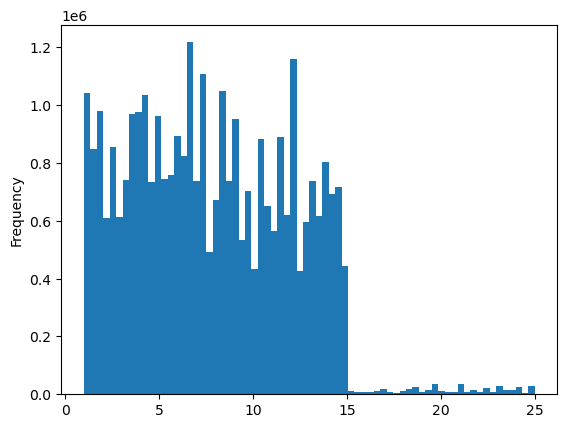

In [21]:
hist = df['prices'].plot.hist(bins = 70)

In [22]:
hist.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'hist_prices.png'))

## Linecharts

The data set is too large so we will need to use sampling. 

### Sampling

In [17]:
np.random.seed(4)
dev = np.random.rand(len(df)) <= 0.7
big = df[dev]
small = df[~dev]

In [18]:
df_2 = small[['orders_day_of_week','prices']]

### Chart

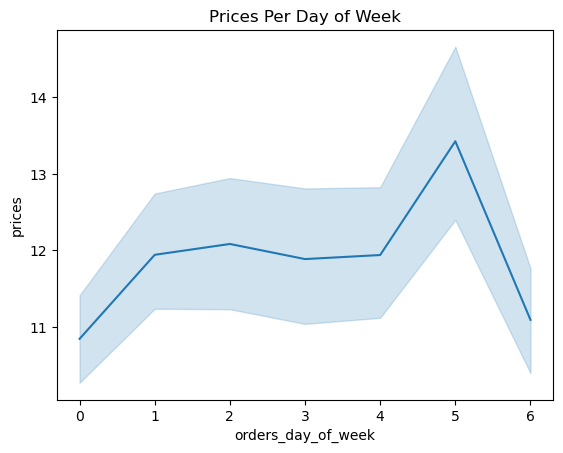

In [21]:
line = sns.lineplot(data = df_2, x = 'orders_day_of_week',y = 'prices').set(title = 'Prices Per Day of Week')

In [ ]:
line.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'prices_dow.png'))

# 04 Export Data Frame

I cleaned some data here so I am rewriting the file. 

In [32]:
#df_merged_large.to_csv(os.path.join(path, '02 Data','Prepared Data', 'orders_products_combined.csv'))
df.to_pickle(os.path.join(path, '02 Data','Prepared Data', 'ords_prods_grouped_indicators_cleaned.pkl'))